In [17]:
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

import joblib

In [3]:
df = pd.read_csv("../data/processed/creditcard_processed.csv")

X = df.drop("Class", axis=1)
y = df["Class"]
df.duplicated().sum()


np.int64(0)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


In [18]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

legitimate_weight = sample_weights[y_train.to_numpy() == 0][0]
fraud_weight = sample_weights[y_train.to_numpy() == 1][0]

print("Sample weights calculated.")
print(f"Legitimate (Class 0) weight: {legitimate_weight:.4f}")
print(f"Fraud (Class 1) weight:      {fraud_weight:.4f}")
print(f"Fraud / Legitimate ratio:    {fraud_weight / legitimate_weight:.1f}x")

Sample weights calculated.
Legitimate (Class 0) weight: 0.5008
Fraud (Class 1) weight:      300.2381
Fraud / Legitimate ratio:    599.5x


In [19]:
model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1
)
# fit the model with sample weights
model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

      Iter       Train Loss   Remaining Time 
         1           1.2301           15.99m
         2           1.1008           16.06m
         3           0.9921           16.84m
         4           0.9015           16.47m
         5           0.8248           15.99m
         6           0.7559           15.58m
         7           0.6964           15.27m
         8           0.6461           15.10m
         9           0.6017           14.83m
        10           0.5625           14.82m
        20           0.3199           12.94m
        30           0.2176           10.94m
        40           0.1645            9.17m
        50           0.1374            7.58m
        60           0.1199            6.00m
        70           0.1037            4.42m
        80           0.0915            2.88m
        90           0.0817            1.40m
       100           0.0738            0.00s


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: int, default=0Enable verbose output. If 1 then it prints progress and performanceonce in a while (the more trees the lower the frequency). If greaterthan 1 then it prints progress and performance for every tree.Values must be in the range `[0, inf)`.",1
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3


In [20]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.19      0.83      0.30        95

    accuracy                           0.99     56746
   macro avg       0.59      0.91      0.65     56746
weighted avg       1.00      0.99      1.00     56746



In [23]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

Precision: 0.1850
Recall:    0.8316
F1-score:  0.3027
PR-AUC:    0.7004


In [24]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56303
False Positives: 348
False Negatives: 16
True Positives  : 79


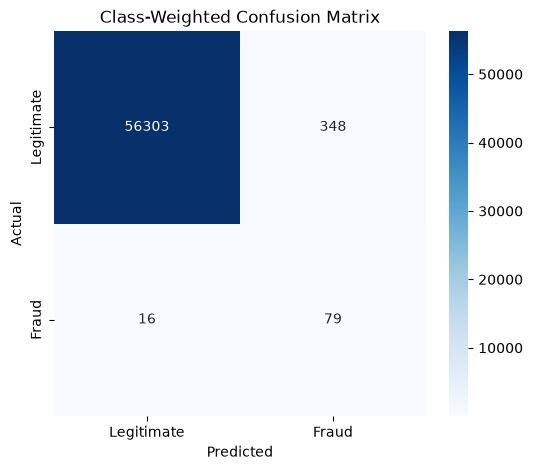

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Class-Weighted Confusion Matrix")

plt.show()

In [26]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

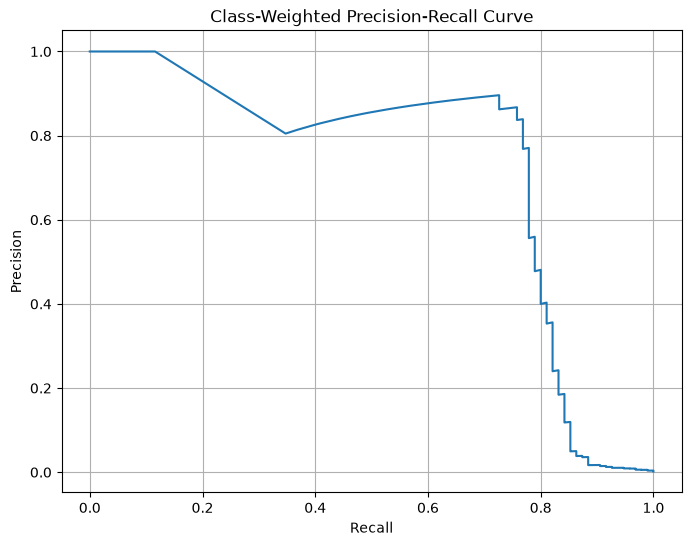

In [27]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Class-Weighted Precision-Recall Curve")

plt.grid()

plt.show()

In [28]:
joblib.dump(
    model,
    "../models/class_weight_model.pkl"
)

print("Class-weighted model saved successfully.")

Class-weighted model saved successfully.
